<a href="https://colab.research.google.com/github/phmlehau/TH_DeepLearning/blob/main/Lap3_TH_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import numpy as np
import pandas as pd

# Data visualization packages
import matplotlib.pyplot as plt

# Keras / Tensorflow packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout

# Model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate

In [45]:
# Tải bộ dataset mnist có sẵn trong tensorflow
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Kiểm tra kích thước dữ liệu
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [46]:
# Đưa dữ liệu ảnh về cấu trúc 4D: (Số lượng mẫu, Chiều cao, Chiều rộng, Số kênh màu)
# Ảnh MNIST là ảnh xám nên số kênh màu (channels) = 1
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

# Ép kiểu dữ liệu về dạng float32
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Chuẩn hóa dữ liệu pixel từ khoảng [0, 255] về khoảng [0, 1]
X_train /= 255
X_test /= 255

# Kiểm tra số lượng phân lớp (classes) đầu ra
print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


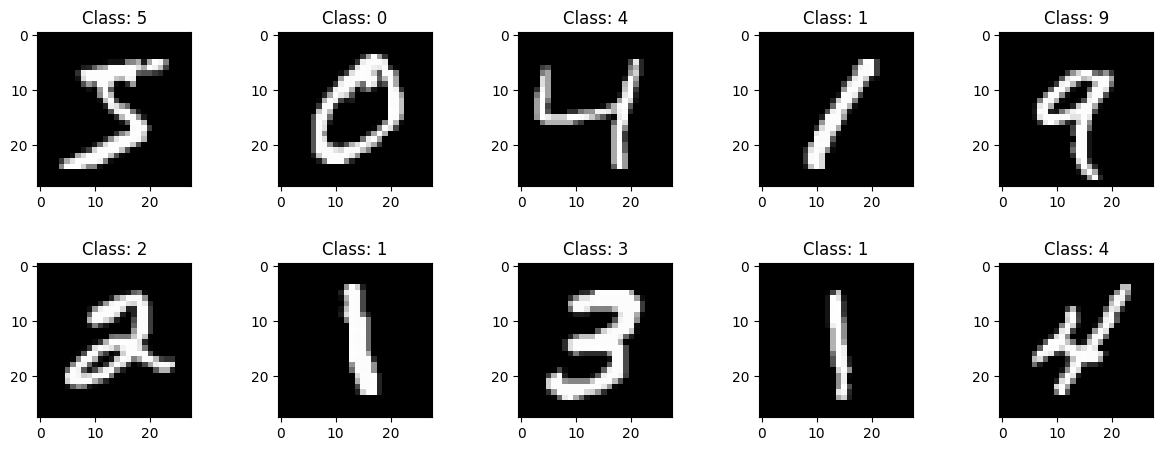

In [47]:
# Tạo khung vẽ 2 hàng, 5 cột để hiển thị 10 hình ảnh số viết tay đầu tiên
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax[i].title.set_text("Class: " + str(y_train[i]))

plt.subplots_adjust(hspace=0.5)
plt.show()

In [48]:
# Khởi tạo mô hình mạng tuần tự
cnn_model = Sequential()

# Tầng 1: Convolutional Layer (Lớp tích chập) với 32 bộ lọc kích thước 3x3, hàm kích hoạt ReLU
cnn_model.add(Convolution2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Tầng 2: Max Pooling Layer (Lớp lấy mẫu cực đại) với cửa sổ kích thước 2x2
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Tầng 3: Flatten Layer (Làm phẳng ma trận đặc trưng thành vector 1 chiều)
cnn_model.add(Flatten())

# Tầng 4: Dense Layer (Lớp kết nối đầy đủ ẩn) với 128 nodes, hàm kích hoạt ReLU
cnn_model.add(Dense(units=128, activation='relu'))

# Tầng 5: Output Layer (Lớp đầu ra) với 10 nodes tương ứng 10 chữ số, hàm kích hoạt Softmax
cnn_model.add(Dense(units=10, activation='softmax'))

# Biên dịch mô hình mạng CNN
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị tóm tắt cấu trúc mạng cấu hình tham số
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Tiến hành khớp dữ liệu huấn luyện, trích xuất 10% làm tập đánh giá kiểm thử validation qua 15 epochs
model_fit = cnn_model.fit(X_train, y_train, validation_split=0.1, epochs=15, verbose=1)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9526 - loss: 0.1590 - val_accuracy: 0.9830 - val_loss: 0.0608
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9841 - loss: 0.0524 - val_accuracy: 0.9870 - val_loss: 0.0451
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9897 - loss: 0.0327 - val_accuracy: 0.9882 - val_loss: 0.0476
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9933 - loss: 0.0213 - val_accuracy: 0.9872 - val_loss: 0.0510
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9951 - loss: 0.0147 - val_accuracy: 0.9878 - val_loss: 0.0535
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9970 - loss: 0.0098 - val_accuracy: 0.9890 - val_loss: 0.0556
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - accuracy: 0.9971 - loss: 0.0089 - val_accuracy: 0.9835 - val_loss: 0.0699
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9980 -

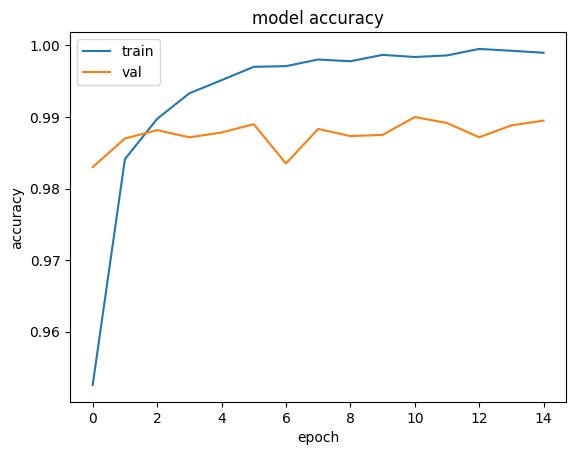

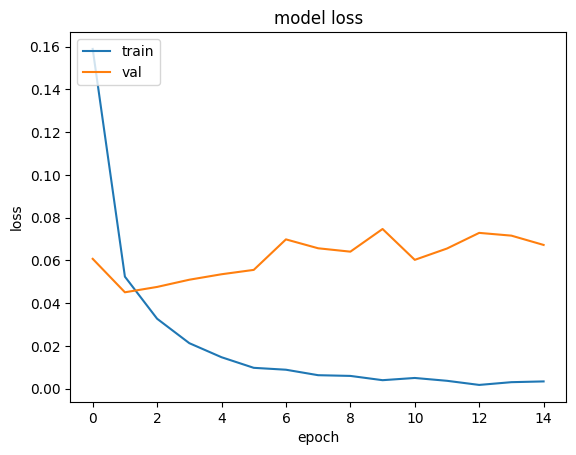

In [50]:
# Vẽ đồ thị biểu diễn Độ chính xác (Accuracy) qua từng vòng lặp (epochs)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Vẽ đồ thị biểu diễn Độ mất mát (Loss) qua từng vòng lặp (epochs)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [51]:
# Đánh giá và tính toán độ lỗi, độ chính xác trên tập dữ liệu X_test, y_test
score = cnn_model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 1s - 4ms/step - accuracy: 0.9872 - loss: 0.0613
Test loss: 0.061348315328359604
Test accuracy: 0.9872000217437744


In [52]:
# Dự đoán lớp cho hình ảnh kiểm thử đầu tiên (Index 0)
print("Predicted label for index 0:", np.argmax(cnn_model.predict(X_test)[0]), "| True label:", y_test[0])

# Dự đoán lớp cho hình ảnh kiểm thử thứ 11 (Index 10)
print("Predicted label for index 10:", np.argmax(cnn_model.predict(X_test)[10]), "| True label:", y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted label for index 0: 7 | True label: 7
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted label for index 10: 0 | True label: 0


In [53]:
# Lưu toàn bộ cấu trúc và trọng số mạng CNN thành một tệp tin
cnn_model.save("cnn_mnist_model.h5")
print("Mô hình đã được lưu thành công vào file 'cnn_mnist_model.h5'")

Mô hình đã được lưu thành công vào file 'cnn_mnist_model.h5'
